Library 1:
  Time to target:         15.51 hr
  Time to first dilution: Not detected
Library 2:
  Time to target:         15.33 hr
  Time to first dilution: Not detected
Empty Vector:
  Time to target:         24.20 hr
  Time to first dilution: Not detected
Library 3:
  Time to target:         14.54 hr
  Time to first dilution: Not detected


/var/folders/wp/m7qlvkrx4rbcjsphypdgzptr0000gn/T/ipykernel_99747/1689997967.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pioreactor_unit', group_keys=False).apply(iqr_filter)
/var/folders/wp/m7qlvkrx4rbcjsphypdgzptr0000gn/T/ipykernel_99747/1689997967.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('pioreactor_unit', group_keys=False).apply(convert)
/var/folders/wp/m7qlvkr

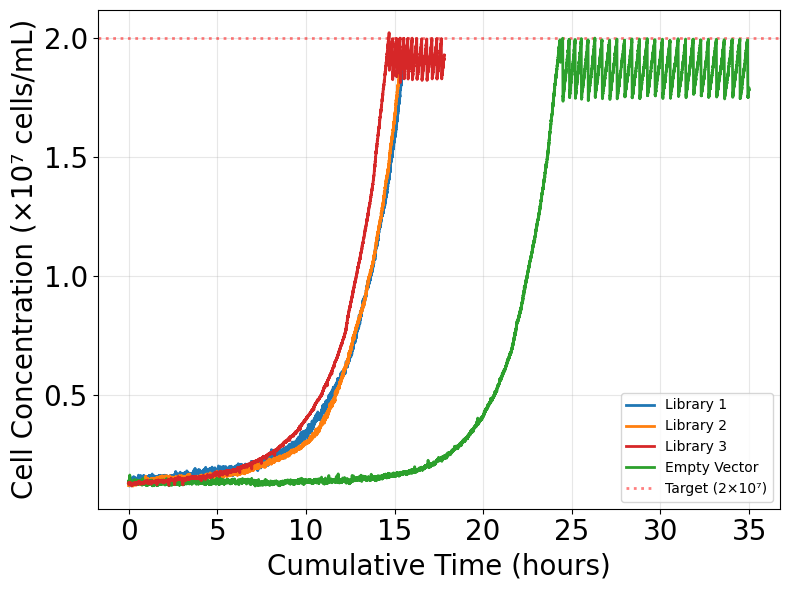

In [ ]:
"""
Analyze growth phases from Pioreactor turbidostat experiments (raw OD)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Configuration ─────────────────────────────────────────────────────────────
OD_FILES          = ["/../../Data/Figure_5/pioreactor_output.csv"]
TARGET_PIOREACTORS = ['Pioreactor02', 'Pioreactor03', 'Pioreactor04', 'Pioreactor09']
DISPLAY_NAMES     = {
    'Pioreactor02': 'Library 1',
    'Pioreactor03': 'Library 2',
    'Pioreactor09': 'Library 3',
    'Pioreactor04': 'Empty Vector',
}
LEGEND_ORDER       = ['Library 1', 'Library 2', 'Library 3', 'Empty Vector']
TRUNCATE_AT_TARGET = ['Pioreactor02', 'Pioreactor03']
TARGET_DENSITY     = 2e7
REFERENCE_UNIT     = 'Pioreactor09'
REFERENCE_PARAMS   = (0.08, 20.57)
NORMALIZE_UNITS    = ['Pioreactor02', 'Pioreactor03']

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.concat([pd.read_csv(fp) for fp in OD_FILES], ignore_index=True)
df.columns = df.columns.str.strip()
df['pioreactor_unit'] = df['pioreactor_unit'].astype(str).str.strip()
df['timestamp']       = pd.to_datetime(df['timestamp'], utc=True)
df = df[df['pioreactor_unit'].isin(TARGET_PIOREACTORS)].sort_values(['pioreactor_unit', 'timestamp'])
df['cumulative_time_hr'] = df.groupby('pioreactor_unit')['timestamp'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600)

# ── Outlier removal (IQR per pioreactor) ──────────────────────────────────────
def iqr_filter(g):
    Q1, Q3 = g['od_reading'].quantile([0.25, 0.75])
    return g[g['od_reading'].between(Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1))]

df = df.groupby('pioreactor_unit', group_keys=False).apply(iqr_filter)

# ── Convert OD to cells/mL ────────────────────────────────────────────────────
a, b   = REFERENCE_PARAMS
ref_min = (a + b * df[df['pioreactor_unit'] == REFERENCE_UNIT]['od_reading'].min()) * 1e7

def convert(group):
    od = group['od_reading']
    if group.name == REFERENCE_UNIT:
        group['cells_per_mL'] = (a + b * od) * 1e7
    else:
        od_min, od_max = od.min(), od.max()
        group['cells_per_mL'] = ref_min + (od - od_min) / (od_max - od_min) * (TARGET_DENSITY - ref_min)
    return group

df = df.groupby('pioreactor_unit', group_keys=False).apply(convert)

# ── Truncate post-target data ─────────────────────────────────────────────────
def truncate(group):
    if group.name not in TRUNCATE_AT_TARGET:
        return group
    above = group[group['cells_per_mL'] >= 0.95 * TARGET_DENSITY]
    return group[group['cumulative_time_hr'] <= above.iloc[0]['cumulative_time_hr']] if len(above) else group

df = df.groupby('pioreactor_unit', group_keys=False).apply(truncate)

# ── Growth phase metrics ───────────────────────────────────────────────────────
def time_to_target(data):
    above = data[data['cells_per_mL'] >= 0.95 * TARGET_DENSITY]
    return above.iloc[0]['cumulative_time_hr'] if len(above) else np.nan

def time_to_first_dilution(data):
    above = data[data['cells_per_mL'] >= 0.95 * TARGET_DENSITY]
    if len(above) == 0:
        return np.nan
    post  = data.loc[above.index[0]:]
    cells = post['cells_per_mL'].values
    times = post['cumulative_time_hr'].values
    drops = np.where(np.diff(cells) / cells[:-1] < -0.10)[0]
    return times[drops[0] + 1] if len(drops) else np.nan

metrics = {
    unit: {
        'time_to_target_hr':         time_to_target(grp.sort_values('cumulative_time_hr')),
        'time_to_first_dilution_hr': time_to_first_dilution(grp.sort_values('cumulative_time_hr')),
    }
    for unit, grp in df.groupby('pioreactor_unit')
}

# ── Print summary ─────────────────────────────────────────────────────────────
for unit in TARGET_PIOREACTORS:
    if unit not in metrics:
        continue
    m = metrics[unit]
    t_t = m['time_to_target_hr']
    t_d = m['time_to_first_dilution_hr']
    print(f"{DISPLAY_NAMES.get(unit, unit)}:")
    print(f"  Time to target:         {t_t:.2f} hr" if not np.isnan(t_t) else "  Time to target: Not detected")
    print(f"  Time to first dilution: {t_d:.2f} hr" if not np.isnan(t_d) else "  Time to first dilution: Not detected")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
scale = 1e7
ax.axhline(y=TARGET_DENSITY / scale, color='red', linestyle=':', linewidth=2, alpha=0.5)

handles_dict = {}
for unit, group in df.groupby('pioreactor_unit'):
    label = DISPLAY_NAMES.get(unit, unit)
    line, = ax.plot(group['cumulative_time_hr'], group['cells_per_mL'] / scale, label=label, linewidth=2)
    handles_dict[label] = line

ordered_handles = [handles_dict[n] for n in LEGEND_ORDER if n in handles_dict]
ordered_labels  = [n for n in LEGEND_ORDER if n in handles_dict]
ordered_handles.append(ax.get_lines()[0])
ordered_labels.append('Target (2×10⁷)')

ax.set_xlabel('Cumulative Time (hours)', fontsize=20)
ax.set_ylabel('Cell Concentration (×10⁷ cells/mL)', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
ax.legend(ordered_handles, ordered_labels, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.show()